In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # fix Windows OpenMP DLL conflict
print("Environment set")

Environment set


In [2]:
import torch
print("PyTorch imported successfully")

PyTorch imported successfully


In [3]:
import csv          # writing training logs to CSV
import json         # saving summary stats as JSON
import time         # measuring training duration
import warnings
warnings.filterwarnings("ignore")   # suppress noisy transformers warnings
from pathlib import Path            # cross-platform file paths

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch                        # PyTorch — the deep learning framework
from torch.utils.data import Dataset, DataLoader   # custom dataset + batch loader

from transformers import (
    AutoTokenizer,                          # loads the right tokenizer for any HF model
    AutoModelForSequenceClassification,     # loads model with a classification head
    get_linear_schedule_with_warmup,        # learning rate scheduler
)

from sklearn.metrics import (
    f1_score,               # F1 score — harmonic mean of precision and recall
    accuracy_score,         # simple % correct
    classification_report,  # per-class precision, recall, F1 table
    confusion_matrix,       # NxN matrix of true vs predicted labels
    cohen_kappa_score,      # inter-rater agreement corrected for chance
    matthews_corrcoef,      # MCC — best single metric for imbalanced classes
)
from scipy.stats import pearsonr    # Pearson correlation between predictions and gold scores

print(f"PyTorch  version : {torch.__version__}")
print(f"Device available : {'CUDA — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(torch.cuda.amp.GradScaler())
print(type(torch.cuda.amp.GradScaler()))

PyTorch  version : 2.11.0+cu128
Device available : CUDA — NVIDIA GeForce RTX 5060 Laptop GPU
<class 'torch.cuda.amp.grad_scaler.GradScaler'>


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data/splits")
MODELS_DIR = Path("../models")
EVAL_DIR   = Path("../evaluation")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)
(EVAL_DIR / "predictions").mkdir(exist_ok=True)
(EVAL_DIR / "figures").mkdir(exist_ok=True)

# ── Label mapping ──────────────────────────────────────────────────────────────
LABEL2ID  = {"ENTAILMENT": 0, "NEUTRAL": 1, "CONTRADICTION": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3
NLI_ORDER  = ["ENTAILMENT", "NEUTRAL", "CONTRADICTION"]

# ── Training hyperparameters ───────────────────────────────────────────────────
EPOCHS        = 5
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5    # default LR for all models

# mDeBERTa-v3 needs a lower LR — 2e-5 with fp16 causes loss=nan due to
# gradient overflow in its disentangled attention mechanism
MDEBERTA_LR   = 1e-5

MAX_LENGTH    = 128
WARMUP_RATIO  = 0.1
SEED          = 42

# ── Models to train ────────────────────────────────────────────────────────────
MODELS_TO_TRAIN = {
    # "infoxlm":  "microsoft/infoxlm-base",
    # "mdeberta": "microsoft/mdeberta-v3-base",
    "mbert":    "google-bert/bert-base-multilingual-cased",
    "xlmr":     "FacebookAI/xlm-roberta-base",
}

# ── Device ─────────────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {device}")
print(f"Models   : {list(MODELS_TO_TRAIN.keys())}")
print(f"Default LR: {LEARNING_RATE}  |  mDeBERTa LR: {MDEBERTA_LR}")

Device   : cuda
Models   : ['mbert', 'xlmr']
Default LR: 2e-05  |  mDeBERTa LR: 1e-05


In [5]:
# Load the three CSV splits produced by 02_eda_and_split.ipynb.
# These were created with a stratified 80/10/10 split by nli_label.
train_df = pd.read_csv(DATA_DIR / "train.csv", low_memory=False)
val_df   = pd.read_csv(DATA_DIR / "val.csv",   low_memory=False)
test_df  = pd.read_csv(DATA_DIR / "test.csv",  low_memory=False)

print(f"Train : {len(train_df):,} rows")
print(f"Val   : {len(val_df):,} rows")
print(f"Test  : {len(test_df):,} rows")
print()

# Show label distribution — important to verify stratification worked correctly.
# All three splits should have roughly the same % per label.
print("Label distribution:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    vc = df["nli_label"].value_counts()
    row = "  ".join(f"{l}={vc.get(l,0):,}({vc.get(l,0)/len(df):.0%})" for l in NLI_ORDER)
    print(f"  {name:5}: {row}")

Train : 14,933 rows
Val   : 1,867 rows
Test  : 1,867 rows

Label distribution:
  Train: ENTAILMENT=3,540(24%)  NEUTRAL=7,726(52%)  CONTRADICTION=3,667(25%)
  Val  : ENTAILMENT=442(24%)  NEUTRAL=966(52%)  CONTRADICTION=459(25%)
  Test : ENTAILMENT=443(24%)  NEUTRAL=966(52%)  CONTRADICTION=458(25%)


In [6]:
class NLIDataset(Dataset):
    """
    PyTorch Dataset for NLI pairs.
    Each item is a tokenized (text_a, text_b) pair with its label.
    """

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        # Store the raw lists — faster than per-row DataFrame access inside __getitem__
        self.texts_a    = df["text_a"].fillna("").tolist()   # article 1 headlines
        self.texts_b    = df["text_b"].fillna("").tolist()   # article 2 headlines
        self.labels     = df["label_id"].tolist()            # 0=ENTAIL 1=NEUTRAL 2=CONTRA
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        # PyTorch needs to know the dataset size for batching
        return len(self.labels)

    def __getitem__(self, idx):
        # Called once per sample per epoch. Tokenizes on-the-fly.
        enc = self.tokenizer(
            self.texts_a[idx],          # first sentence (article A headline)
            self.texts_b[idx],          # second sentence (article B headline)
            max_length=self.max_length, # pad/truncate to this length
            padding="max_length",       # pad shorter sequences to max_length
            truncation=True,            # cut sequences longer than max_length
            return_tensors="pt",        # return PyTorch tensors (not numpy/lists)
        )
        return {
            # squeeze(0) removes the batch dimension tokenizer adds by default
            "input_ids":      enc["input_ids"].squeeze(0),       # token IDs
            "attention_mask": enc["attention_mask"].squeeze(0),  # 1=real token, 0=padding
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

print("NLIDataset class defined")

NLIDataset class defined


In [7]:
def compute_all_metrics(y_true: list, y_pred: list,
                        overall_scores: list = None) -> dict:
    """
    Compute all 8 metrics required for the capstone evaluation.

    Parameters
    ----------
    y_true          : list of int  — gold label IDs (0/1/2) from test.csv
    y_pred          : list of int  — model predicted label IDs (0/1/2)
    overall_scores  : list of float — raw OVERALL similarity scores (1-4 scale)
                      used for Pearson r. Optional — pass None if unavailable.

    Returns
    -------
    dict with all 8 metric values
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ── 1. F1 Macro ────────────────────────────────────────────────────────────
    # Average F1 across all 3 classes, treating each class equally regardless
    # of how many examples it has. This is the primary metric for NLI.
    # Formula: (F1_ENTAIL + F1_NEUTRAL + F1_CONTRA) / 3
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # ── 2-4. Per-class F1 ─────────────────────────────────────────────────────
    # F1 for each label independently. Useful to diagnose which class
    # the model struggles with. F1 = 2 * (precision * recall) / (precision + recall)
    # where precision = TP / (TP + FP) and recall = TP / (TP + FN)
    f1_per_class = f1_score(
        y_true, y_pred,
        average=None,       # returns an array of F1 per class [ENTAIL, NEUTRAL, CONTRA]
        labels=[0, 1, 2],   # must match LABEL2ID order
        zero_division=0,    # returns 0 instead of warning when a class has no predictions
    )

    # ── 5. Accuracy ───────────────────────────────────────────────────────────
    # Fraction of all predictions that are exactly correct.
    # Simple but misleading for imbalanced classes — use Macro F1 as primary.
    accuracy = accuracy_score(y_true, y_pred)

    # ── 6. Cohen's Kappa ──────────────────────────────────────────────────────
    # Measures agreement between model and gold labels, CORRECTED for chance.
    # A model that randomly guesses would get kappa ≈ 0.
    # Perfect agreement = 1.0. Better than raw accuracy for NLI evaluation.
    # Interpretation: <0=worse than chance, 0-0.2=slight, 0.2-0.4=fair,
    #                 0.4-0.6=moderate, 0.6-0.8=substantial, 0.8-1.0=near perfect
    kappa = cohen_kappa_score(y_true, y_pred)

    # ── 7. Matthews Correlation Coefficient (MCC) ─────────────────────────────
    # Best single metric for multi-class imbalanced problems.
    # Uses all cells of the confusion matrix (TP, TN, FP, FN for each class).
    # Range: -1 (completely wrong) to 0 (random) to +1 (perfect).
    # Unlike F1, MCC penalises being wrong in ALL directions equally.
    mcc = matthews_corrcoef(y_true, y_pred)

    # ── 8. Pearson r ──────────────────────────────────────────────────────────
    # Measures linear correlation between the predicted label IDs (0/1/2)
    # and the original continuous OVERALL similarity scores (1.0–4.0).
    # High r means the model's confidence ordering matches the human scores.
    # Only meaningful if overall_scores is provided (they come from test.csv).
    if overall_scores is not None and len(overall_scores) == len(y_pred):
        scores_arr = np.array(overall_scores, dtype=float)
        # pearsonr returns (correlation, p_value) — we only want the correlation
        pearson_r, pearson_p = pearsonr(y_pred.astype(float), scores_arr)
    else:
        pearson_r, pearson_p = float("nan"), float("nan")

    return {
        "f1_macro":          round(float(f1_macro),        4),
        "f1_entailment":     round(float(f1_per_class[0]), 4),  # LABEL2ID["ENTAILMENT"]=0
        "f1_neutral":        round(float(f1_per_class[1]), 4),  # LABEL2ID["NEUTRAL"]=1
        "f1_contradiction":  round(float(f1_per_class[2]), 4),  # LABEL2ID["CONTRADICTION"]=2
        "accuracy":          round(float(accuracy),         4),
        "cohen_kappa":       round(float(kappa),            4),
        "matthews_mcc":      round(float(mcc),              4),
        "pearson_r":         round(float(pearson_r),        4),
        "pearson_p":         round(float(pearson_p),        6) if not np.isnan(pearson_p) else "nan",
    }

print("compute_all_metrics() defined")
print("Metrics computed: f1_macro, f1_entailment, f1_neutral, f1_contradiction,")
print("                  accuracy, cohen_kappa, matthews_mcc, pearson_r")

compute_all_metrics() defined
Metrics computed: f1_macro, f1_entailment, f1_neutral, f1_contradiction,
                  accuracy, cohen_kappa, matthews_mcc, pearson_r


In [8]:
def train_one_model(model_key, hf_name, train_df, val_df, lr=None):
    """
    Fine-tune one model — pure fp32, no scaler, no autocast.
    Works identically on CPU and GPU with zero fp16-related errors.
    mDeBERTa gets lr=1e-5 automatically; all others get lr=2e-5.
    """
    # mDeBERTa needs lower LR — its disentangled attention is unstable at 2e-5
    if lr is None:
        lr = MDEBERTA_LR if model_key == "mdeberta" else LEARNING_RATE

    print(f"\n{'='*65}")
    print(f"  Training : {model_key}  ({hf_name})")
    print(f"  Train    : {len(train_df):,}  |  Val: {len(val_df):,}")
    print(f"  LR       : {lr}  |  precision: fp32 (no scaler)")
    print(f"{'='*65}")

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    out_dir = MODELS_DIR / model_key
    out_dir.mkdir(parents=True, exist_ok=True)

    # Load tokenizer
    print("  Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(hf_name)

    # Load model with 3-class classification head
    print("  Loading model (downloads on first run)...")
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_name,
        num_labels=NUM_LABELS,
        label2id=LABEL2ID,
        id2label=ID2LABEL,
        ignore_mismatched_sizes=True,
    )
    model.to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {n_params/1e6:.1f}M  |  Device: {device}")

    # Data loaders — num_workers=0 avoids Windows multiprocessing issues
    train_ds = NLIDataset(train_df, tokenizer, MAX_LENGTH)
    val_ds   = NLIDataset(val_df,   tokenizer, MAX_LENGTH)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,   shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

    # AdamW optimiser with linear warmup + decay scheduler
    optimizer    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(train_dl) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    print(f"  Steps    : {total_steps}  |  Warmup: {warmup_steps}")

    log_rows    = []
    best_val_f1 = -1.0
    t_start     = time.time()

    for epoch in range(1, EPOCHS + 1):

        # ── TRAIN ──────────────────────────────────────────────────────────────
        model.train()
        train_loss, n_train = 0.0, 0
        ep_start = time.time()

        for step, batch in enumerate(train_dl, 1):
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["labels"].to(device)

            optimizer.zero_grad()

            # Standard fp32 forward + backward — no scaler, no autocast
            out  = model(input_ids=input_ids,
                         attention_mask=attn_mask,
                         labels=labels)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item() * input_ids.size(0)
            n_train    += input_ids.size(0)

            if step % 100 == 0:
                sps = n_train / (time.time() - ep_start)
                print(f"    Epoch {epoch} | step {step:4d}/{len(train_dl)} "
                      f"| loss {train_loss/n_train:.4f} | {sps:.0f} samp/s")

        avg_train_loss = train_loss / n_train

        # ── VALIDATE ───────────────────────────────────────────────────────────
        model.eval()
        all_preds, all_true = [], []
        val_loss, n_val = 0.0, 0

        with torch.no_grad():
            for batch in val_dl:
                input_ids = batch["input_ids"].to(device)
                attn_mask = batch["attention_mask"].to(device)
                labels    = batch["labels"].to(device)

                out = model(input_ids=input_ids,
                            attention_mask=attn_mask,
                            labels=labels)

                val_loss += out.loss.item() * input_ids.size(0)
                n_val    += input_ids.size(0)
                preds     = out.logits.argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_true.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / n_val
        val_f1  = f1_score(all_true, all_preds, average="macro", zero_division=0)
        val_acc = accuracy_score(all_true, all_preds)
        ep_time = time.time() - ep_start

        print(f"\n  Epoch {epoch}/{EPOCHS} "
              f"| train_loss={avg_train_loss:.4f} "
              f"| val_loss={avg_val_loss:.4f} "
              f"| val_f1={val_f1:.4f} "
              f"| val_acc={val_acc:.4f} "
              f"| {ep_time:.0f}s")

        log_rows.append({
            "model":        model_key,
            "epoch":        epoch,
            "train_loss":   round(avg_train_loss, 5),
            "val_loss":     round(avg_val_loss, 5),
            "val_f1_macro": round(val_f1, 5),
            "val_accuracy": round(val_acc, 5),
        })

        # Save best checkpoint (by val macro F1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            model.save_pretrained(out_dir)
            tokenizer.save_pretrained(out_dir)
            print(f"  ✓ New best val_f1={best_val_f1:.4f} → saved to {out_dir}")

    total_time = time.time() - t_start

    # Save training log CSV and summary JSON
    log_df = pd.DataFrame(log_rows)
    log_df.to_csv(out_dir / "training_log.csv", index=False)

    summary = {
        "model_key":         model_key,
        "hf_name":           hf_name,
        "best_val_f1_macro": round(best_val_f1, 5),
        "epochs":            EPOCHS,
        "batch_size":        BATCH_SIZE,
        "learning_rate":     lr,
        "total_train_secs":  round(total_time, 1),
        "train_rows":        len(train_df),
        "val_rows":          len(val_df),
    }
    with open(out_dir / "training_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print(f"\n  Done : {model_key} | {total_time/60:.1f} min | best F1={best_val_f1:.4f}")
    summary["log_df"] = log_df
    return summary

print("train_one_model() defined — fp32 only, no scaler, no autocast")
print(f"  mDeBERTa LR : {MDEBERTA_LR}  |  others LR : {LEARNING_RATE}")

train_one_model() defined — fp32 only, no scaler, no autocast
  mDeBERTa LR : 1e-05  |  others LR : 2e-05


In [9]:
def evaluate_on_test(model_key: str, test_df: pd.DataFrame) -> dict:
    """
    Load the best saved checkpoint and evaluate on the test split.
    Computes all 8 required metrics.
    """
    model_dir = MODELS_DIR / model_key

    # ── Load best checkpoint ───────────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model     = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.to(device)
    model.eval()   # always set eval mode before inference

    # ── Build test dataloader ─────────────────────────────────────────────────
    test_ds = NLIDataset(test_df, tokenizer, MAX_LENGTH)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    # shuffle=False is critical for test — we need predictions to align with rows

    # ── Run inference ──────────────────────────────────────────────────────────
    all_preds, all_probs = [], []

    with torch.no_grad():
        for batch in test_dl:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits

            # softmax converts raw logits to probabilities that sum to 1
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)   # shape: (n_test, 3)
    y_true    = test_df["label_id"].values

    # ── Get OVERALL scores for Pearson r ──────────────────────────────────────
    # OVERALL is the continuous human similarity score (1.0 to 4.0).
    # Pearson r measures how well our discrete predictions correlate with it.
    overall_scores = test_df["OVERALL"].values if "OVERALL" in test_df.columns else None

    # ── Compute all 8 metrics ─────────────────────────────────────────────────
    metrics = compute_all_metrics(y_true, all_preds, overall_scores)
    metrics["model"] = model_key

    # ── Print classification report ────────────────────────────────────────────
    label_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]
    print(f"\n  Classification report — {model_key} on TEST set")
    print(classification_report(y_true, all_preds, target_names=label_names, digits=4))

    # ── Save full prediction file ──────────────────────────────────────────────
    pred_df = test_df[["pair_id","lang_pair","text_a","text_b",
                        "nli_label","label_id"]].copy()
    pred_df["pred_label"]         = [ID2LABEL[p] for p in all_preds]
    pred_df["pred_id"]            = all_preds
    pred_df["prob_entailment"]    = all_probs[:, 0]   # probability for class 0
    pred_df["prob_neutral"]       = all_probs[:, 1]   # probability for class 1
    pred_df["prob_contradiction"] = all_probs[:, 2]   # probability for class 2
    pred_df["correct"]            = (pred_df["label_id"] == pred_df["pred_id"])
    pred_df.to_csv(EVAL_DIR / "predictions" / f"{model_key}_test_preds.csv", index=False)

    return metrics, pred_df

print("evaluate_on_test() defined")

evaluate_on_test() defined


In [10]:
# ── Storage ───────────────────────────────────────────────────────────────────
all_summaries = []
all_metrics   = []
all_pred_dfs  = []

# ── Train + evaluate each model ────────────────────────────────────────────────
# All models train in fp32 (no scaler, no autocast).
# mDeBERTa automatically uses lr=1e-5; all others use lr=2e-5.
for model_key, hf_name in MODELS_TO_TRAIN.items():

    print(f"\n{'#'*65}")
    print(f"#  STARTING: {model_key} ({hf_name})")
    print(f"{'#'*65}")

    # Train
    summary = train_one_model(
        model_key = model_key,
        hf_name   = hf_name,
        train_df  = train_df,
        val_df    = val_df,
    )
    all_summaries.append(summary)

    # Evaluate on test set
    print(f"\n  Evaluating {model_key} on test set...")
    metrics, pred_df = evaluate_on_test(model_key, test_df)
    all_metrics.append(metrics)
    all_pred_dfs.append(pred_df)

    print(f"\n  Metrics — {model_key}:")
    for k, v in metrics.items():
        if k != "model":
            print(f"    {k:<22}: {v}")

print(f"\n{'#'*65}")
print("#  ALL MODELS COMPLETE")
print(f"{'#'*65}")


#################################################################
#  STARTING: mbert (google-bert/bert-base-multilingual-cased)
#################################################################

  Training : mbert  (google-bert/bert-base-multilingual-cased)
  Train    : 14,933  |  Val: 1,867
  LR       : 2e-05  |  precision: fp32 (no scaler)
  Loading tokenizer...
  Loading model (downloads on first run)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6296.85it/s]
BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the 

  Parameters: 177.9M  |  Device: cuda
  Steps    : 4670  |  Warmup: 467
    Epoch 1 | step  100/934 | loss 1.0494 | 79 samp/s
    Epoch 1 | step  200/934 | loss 1.0210 | 80 samp/s
    Epoch 1 | step  300/934 | loss 0.9849 | 80 samp/s
    Epoch 1 | step  400/934 | loss 0.9574 | 80 samp/s
    Epoch 1 | step  500/934 | loss 0.9412 | 80 samp/s
    Epoch 1 | step  600/934 | loss 0.9288 | 80 samp/s
    Epoch 1 | step  700/934 | loss 0.9124 | 80 samp/s
    Epoch 1 | step  800/934 | loss 0.9014 | 79 samp/s
    Epoch 1 | step  900/934 | loss 0.8958 | 79 samp/s

  Epoch 1/5 | train_loss=0.8935 | val_loss=0.8569 | val_f1=0.4627 | val_acc=0.5769 | 199s


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.80s/it]


  ✓ New best val_f1=0.4627 → saved to ..\models\mbert
    Epoch 2 | step  100/934 | loss 0.7275 | 74 samp/s
    Epoch 2 | step  200/934 | loss 0.7358 | 74 samp/s
    Epoch 2 | step  300/934 | loss 0.7351 | 73 samp/s
    Epoch 2 | step  400/934 | loss 0.7289 | 73 samp/s
    Epoch 2 | step  500/934 | loss 0.7322 | 73 samp/s
    Epoch 2 | step  600/934 | loss 0.7336 | 74 samp/s
    Epoch 2 | step  700/934 | loss 0.7316 | 73 samp/s
    Epoch 2 | step  800/934 | loss 0.7311 | 73 samp/s
    Epoch 2 | step  900/934 | loss 0.7275 | 73 samp/s

  Epoch 2/5 | train_loss=0.7268 | val_loss=0.8275 | val_f1=0.5561 | val_acc=0.6026 | 214s


...

  ✓ New best val_f1=0.6172 → saved to ..\models\xlmr
    Epoch 4 | step  100/934 | loss 0.5970 | 26 samp/s
    Epoch 4 | step  200/934 | loss 0.5802 | 29 samp/s
    Epoch 4 | step  300/934 | loss 0.5800 | 31 samp/s
    Epoch 4 | step  400/934 | loss 0.5808 | 31 samp/s
    Epoch 4 | step  500/934 | loss 0.5808 | 27 samp/s
    Epoch 4 | step  600/934 | loss 0.5874 | 28 samp/s
    Epoch 4 | step  700/934 | loss 0.5860 | 29 samp/s
    Epoch 4 | step  800/934 | loss 0.5824 | 29 samp/s
    Epoch 4 | step  900/934 | loss 0.5811 | 29 samp/s

  Epoch 4/5 | train_loss=0.5825 | val_loss=0.9048 | val_f1=0.6195 | val_acc=0.6202 | 602s


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


  ✓ New best val_f1=0.6195 → saved to ..\models\xlmr
    Epoch 5 | step  100/934 | loss 0.5020 | 33 samp/s
    Epoch 5 | step  200/934 | loss 0.4916 | 32 samp/s
    Epoch 5 | step  300/934 | loss 0.4956 | 32 samp/s
    Epoch 5 | step  400/934 | loss 0.4891 | 32 samp/s
    Epoch 5 | step  500/934 | loss 0.4823 | 32 samp/s
    Epoch 5 | step  600/934 | loss 0.4798 | 32 samp/s
    Epoch 5 | step  700/934 | loss 0.4802 | 32 samp/s
    Epoch 5 | step  800/934 | loss 0.4816 | 32 samp/s
    Epoch 5 | step  900/934 | loss 0.4801 | 32 samp/s

  Epoch 5/5 | train_loss=0.4819 | val_loss=1.0007 | val_f1=0.6075 | val_acc=0.6202 | 471s

  Done : xlmr | 42.4 min | best F1=0.6195

  Evaluating xlmr on test set...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10521.88it/s]



  Classification report — xlmr on TEST set
               precision    recall  f1-score   support

   ENTAILMENT     0.5770    0.6343    0.6043       443
      NEUTRAL     0.6859    0.5787    0.6277       966
CONTRADICTION     0.5858    0.7227    0.6471       458

     accuracy                         0.6272      1867
    macro avg     0.6162    0.6452    0.6264      1867
 weighted avg     0.6355    0.6272    0.6269      1867


  Metrics — xlmr:
    f1_macro              : 0.6264
    f1_entailment         : 0.6043
    f1_neutral            : 0.6277
    f1_contradiction      : 0.6471
    accuracy              : 0.6272
    cohen_kappa           : 0.4157
    matthews_mcc          : 0.4193
    pearson_r             : -0.6125
    pearson_p             : 0.0

#################################################################
#  ALL MODELS COMPLETE
#################################################################


In [13]:
# Combine metrics from all models into one DataFrame for easy comparison
results_df = pd.DataFrame(all_metrics)

# Column order — put model name first, then metrics from most to least important
col_order = [
    "model",
    "f1_macro",           # PRIMARY metric — use this to pick the best model
    "accuracy",           # simple correctness
    "cohen_kappa",        # chance-corrected agreement
    "matthews_mcc",       # best for imbalanced classes
    "pearson_r",          # correlation with continuous human scores
    "f1_entailment",      # per-class F1 — shows which classes the model struggles with
    "f1_neutral",
    "f1_contradiction",
    "pearson_p",          # statistical significance of Pearson r
]
results_df = results_df[[c for c in col_order if c in results_df.columns]]

# Sort by macro F1 descending — best model first
results_df = results_df.sort_values("f1_macro", ascending=False).reset_index(drop=True)

# Save to CSV
results_path = EVAL_DIR / "all_models_metrics.csv"
results_df.to_csv(results_path, index=False)

print(f"Metrics saved to: {results_path}")
print()
print("=" * 75)
print("  FINAL RESULTS — ALL MODELS ON TEST SET")
print("=" * 75)
print(results_df.to_string(index=False))
print("=" * 75)
print(f"\n  Best model: {results_df.iloc[0]['model']}  "
      f"(Macro F1 = {results_df.iloc[0]['f1_macro']:.4f})")

Metrics saved to: ..\evaluation\all_models_metrics.csv

  FINAL RESULTS — ALL MODELS ON TEST SET
model  f1_macro  accuracy  cohen_kappa  matthews_mcc  pearson_r  f1_entailment  f1_neutral  f1_contradiction  pearson_p
 xlmr    0.6264    0.6272       0.4157        0.4193    -0.6125         0.6043      0.6277            0.6471        0.0
mbert    0.6068    0.6186       0.3817        0.3821    -0.5590         0.5724      0.6486            0.5992        0.0

  Best model: xlmr  (Macro F1 = 0.6264)


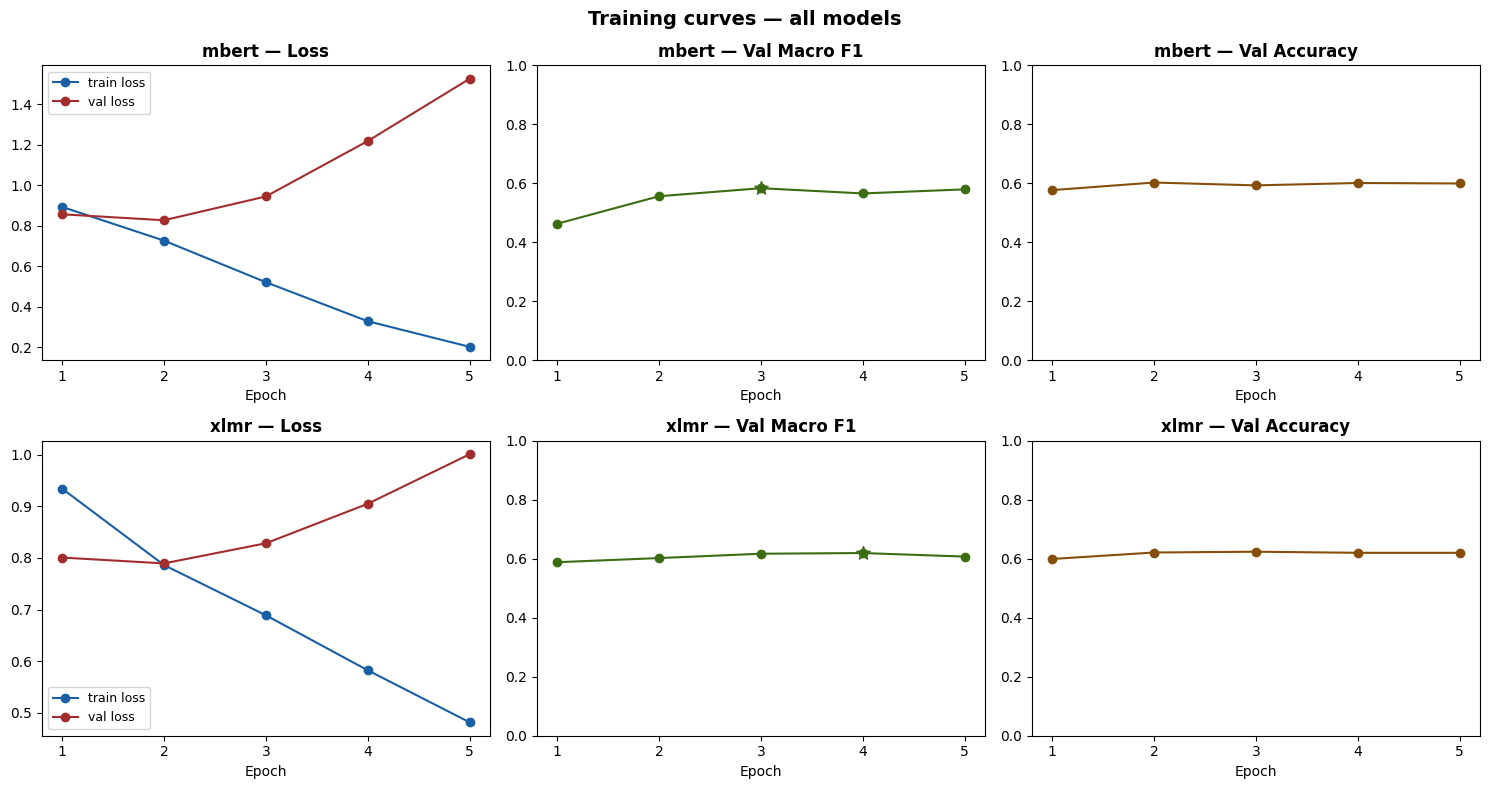

Saved: ..\evaluation\figures\training_curves_all.png


In [14]:
n_models = len(all_summaries)
fig, axes = plt.subplots(n_models, 3, figsize=(15, 4 * n_models))
fig.suptitle("Training curves — all models", fontsize=14, fontweight="bold")

# One row per model, three columns: loss / val F1 / val accuracy
for i, summary in enumerate(all_summaries):
    log = summary["log_df"]   # the per-epoch log DataFrame saved by train_one_model
    key = summary["model_key"]

    # ── Column 0: Train vs Val Loss ────────────────────────────────────────────
    axes[i, 0].plot(log["epoch"], log["train_loss"], "o-", color="#185FA5", label="train loss")
    axes[i, 0].plot(log["epoch"], log["val_loss"],   "o-", color="#A32D2D", label="val loss")
    axes[i, 0].set_title(f"{key} — Loss", fontweight="bold")
    axes[i, 0].set_xlabel("Epoch"); axes[i, 0].legend(fontsize=9)
    axes[i, 0].set_xticks(log["epoch"])

    # ── Column 1: Val Macro F1 ────────────────────────────────────────────────
    axes[i, 1].plot(log["epoch"], log["val_f1_macro"], "o-", color="#3B6D11")
    axes[i, 1].set_title(f"{key} — Val Macro F1", fontweight="bold")
    axes[i, 1].set_xlabel("Epoch"); axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xticks(log["epoch"])
    # Mark the best epoch with a star
    best_ep = log.loc[log["val_f1_macro"].idxmax()]
    axes[i, 1].scatter([best_ep["epoch"]], [best_ep["val_f1_macro"]],
                       color="#3B6D11", zorder=5, s=100, marker="*")

    # ── Column 2: Val Accuracy ────────────────────────────────────────────────
    axes[i, 2].plot(log["epoch"], log["val_accuracy"], "o-", color="#854F0B")
    axes[i, 2].set_title(f"{key} — Val Accuracy", fontweight="bold")
    axes[i, 2].set_xlabel("Epoch"); axes[i, 2].set_ylim(0, 1)
    axes[i, 2].set_xticks(log["epoch"])

plt.tight_layout()
curves_path = EVAL_DIR / "figures" / "training_curves_all.png"
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {curves_path}")

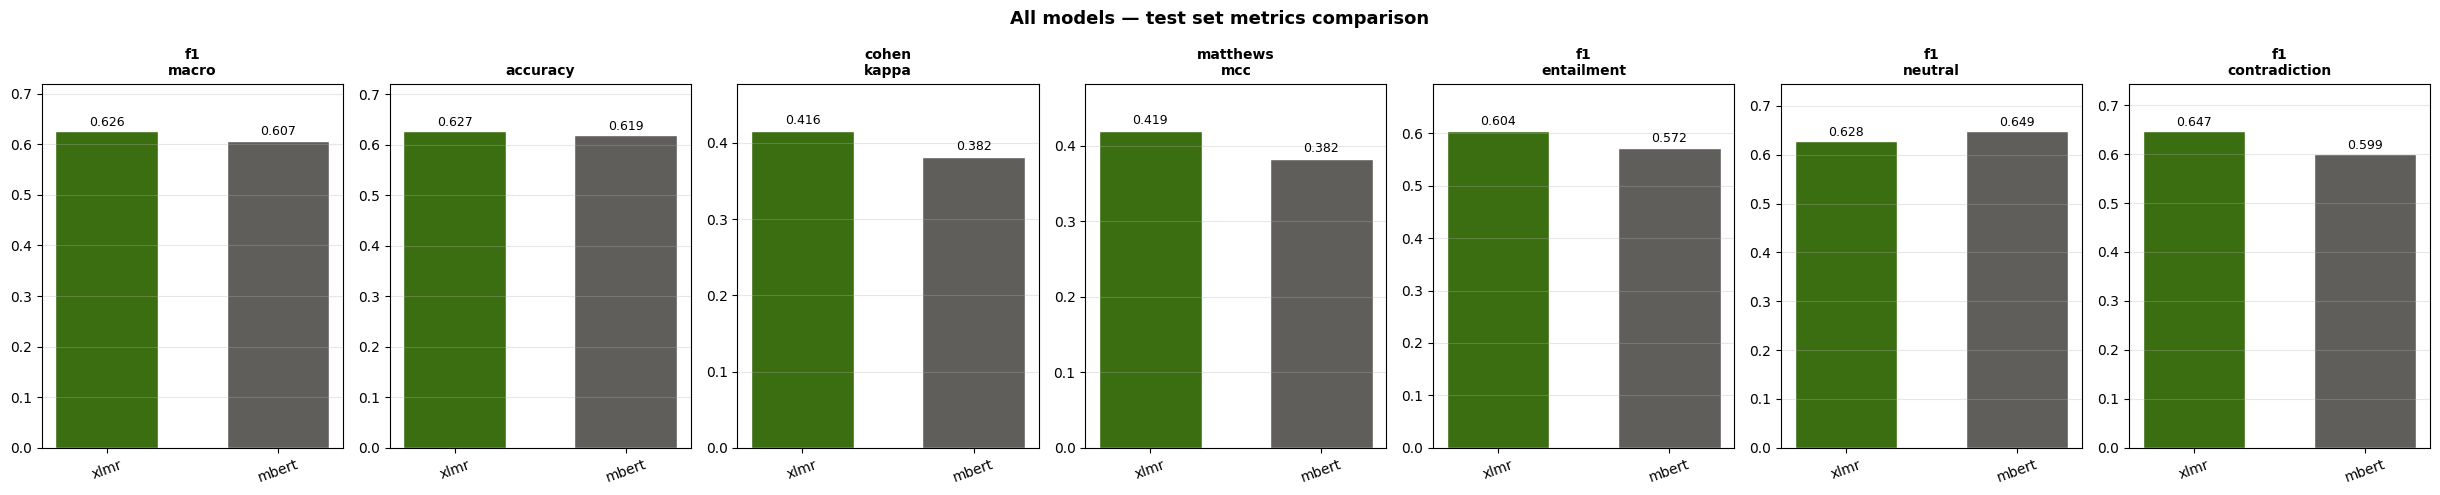

Saved: ..\evaluation\figures\metrics_comparison.png


In [15]:
# Show all 8 metrics side by side for all models
metrics_to_plot = ["f1_macro","accuracy","cohen_kappa","matthews_mcc",
                   "f1_entailment","f1_neutral","f1_contradiction"]

# Filter to only numeric metrics that exist
metrics_to_plot = [m for m in metrics_to_plot if m in results_df.columns]

fig, axes = plt.subplots(1, len(metrics_to_plot),
                          figsize=(3.5 * len(metrics_to_plot), 5))
fig.suptitle("All models — test set metrics comparison", fontsize=13, fontweight="bold")

model_colors = {"mbert": "#5F5E5A", "xlmr": "#3B6D11",
                "infoxlm": "#854F0B", "mdeberta": "#185FA5"}

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        results_df["model"],
        results_df[metric],
        color=[model_colors.get(m, "#888") for m in results_df["model"]],
        edgecolor="white", width=0.6,
    )
    # Add value labels on top of each bar
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(metric.replace("_", "\n"), fontweight="bold", fontsize=10)
    ax.set_ylim(0, min(1.05, results_df[metric].max() * 1.15))
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
bar_path = EVAL_DIR / "figures" / "metrics_comparison.png"
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")

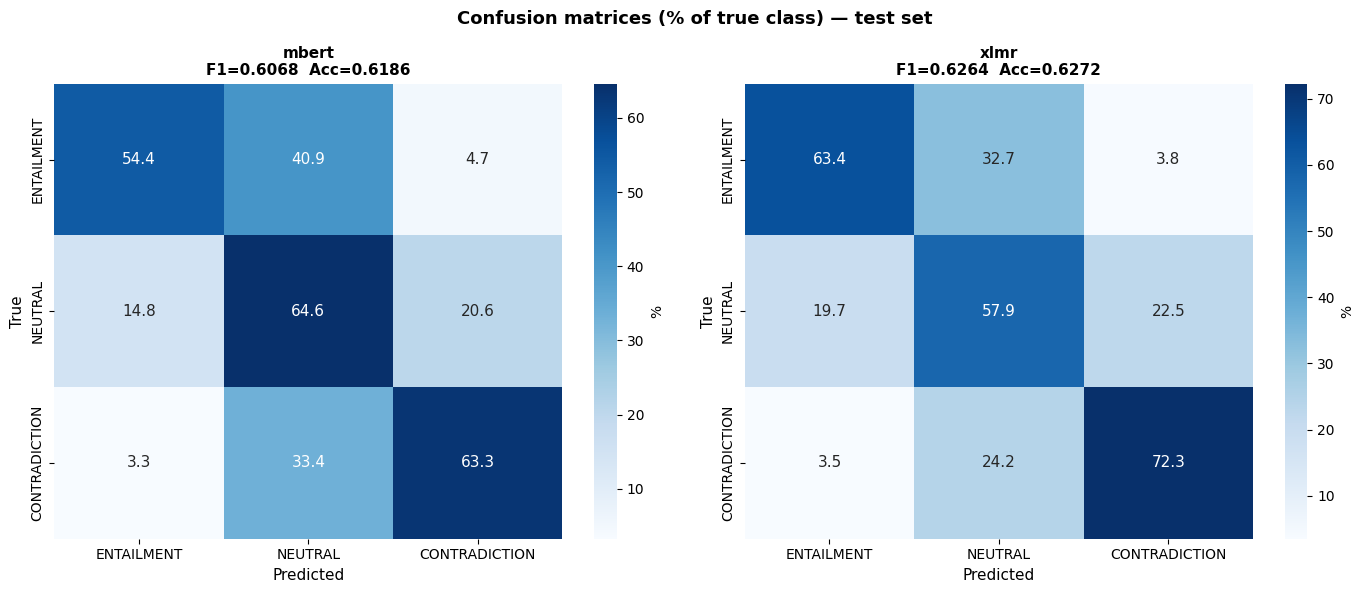

Saved: ..\evaluation\figures\confusion_matrices.png


In [16]:
fig, axes = plt.subplots(1, len(all_metrics), figsize=(7 * len(all_metrics), 6))
if len(all_metrics) == 1:
    axes = [axes]   # ensure axes is always a list
fig.suptitle("Confusion matrices (% of true class) — test set", fontsize=13, fontweight="bold")

label_names = NLI_ORDER

for ax, (metrics, pred_df) in zip(axes, zip(all_metrics, all_pred_dfs)):
    y_true = pred_df["label_id"].values
    y_pred = pred_df["pred_id"].values

    # Build confusion matrix — rows=true label, cols=predicted label
    # Normalised by true label count (row) so each row sums to 100%
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names,
        ax=ax, cbar_kws={"label": "%"}, annot_kws={"size": 11},
    )
    ax.set_title(
        f"{metrics['model']}\n"
        f"F1={metrics['f1_macro']:.4f}  Acc={metrics['accuracy']:.4f}",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)

plt.tight_layout()
cm_path = EVAL_DIR / "figures" / "confusion_matrices.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")

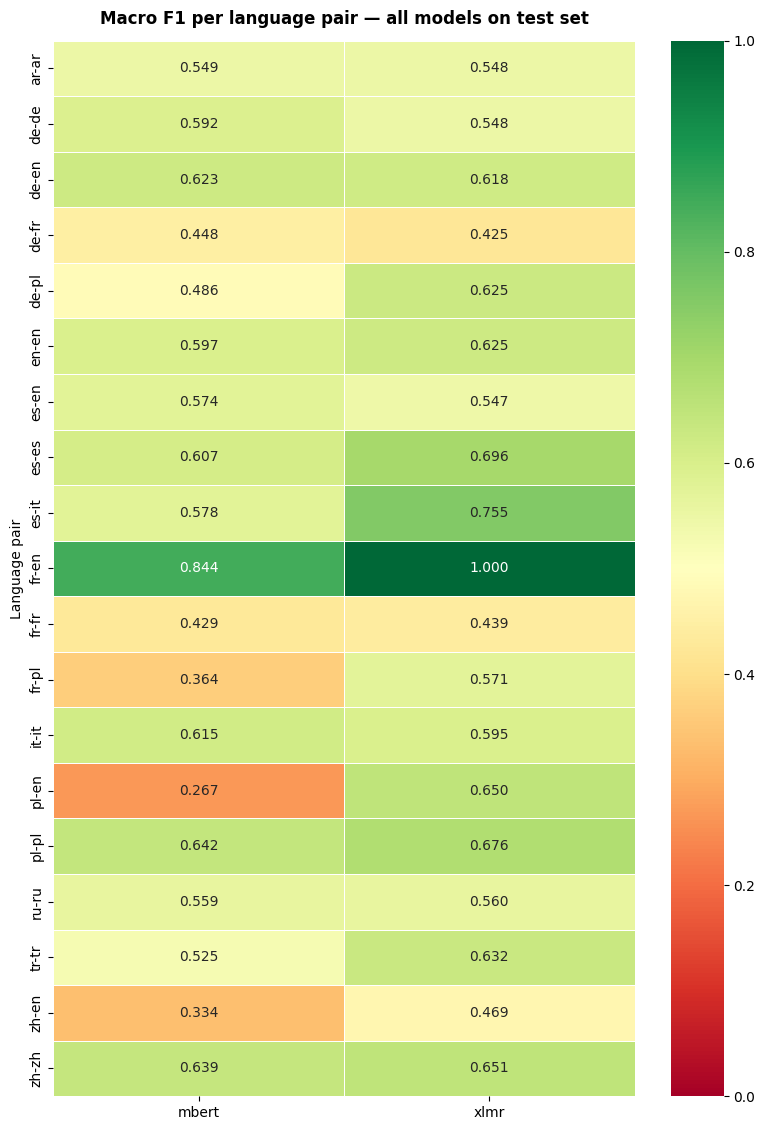

Saved: ..\evaluation\figures\per_lang_pair_f1.png
Saved: ..\evaluation/per_lang_pair_f1.csv


In [17]:
# Shows which language pairs each model handles best and worst.
# This is the key finding section — identifies where cross-lingual transfer helps.

MIN_PAIRS = 5   # minimum test samples needed to include a language pair

lang_rows = []
for metrics, pred_df in zip(all_metrics, all_pred_dfs):
    for pair in sorted(pred_df["lang_pair"].unique()):
        mask = pred_df["lang_pair"] == pair
        if mask.sum() < MIN_PAIRS:
            continue   # skip pairs with too few samples for reliable F1
        pair_f1 = f1_score(
            pred_df[mask]["label_id"].values,
            pred_df[mask]["pred_id"].values,
            average="macro", zero_division=0,
        )
        lang_rows.append({
            "model":     metrics["model"],
            "lang_pair": pair,
            "count":     int(mask.sum()),
            "f1_macro":  round(pair_f1, 4),
        })

lang_df = pd.DataFrame(lang_rows)

# Pivot so rows = language pairs, columns = models
pivot = lang_df.pivot(index="lang_pair", columns="model", values="f1_macro")

fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*2.5),
                                 max(6, len(pivot)*0.6)))
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0, vmax=1, ax=ax,
    linewidths=0.5, annot_kws={"size": 10},
)
ax.set_title("Macro F1 per language pair — all models on test set",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel(""); ax.set_ylabel("Language pair")
plt.tight_layout()
lp_path = EVAL_DIR / "figures" / "per_lang_pair_f1.png"
plt.savefig(lp_path, dpi=150, bbox_inches="tight")
plt.show()

# Also save as CSV
lang_df.to_csv(EVAL_DIR / "per_lang_pair_f1.csv", index=False)
print(f"Saved: {lp_path}")
print(f"Saved: {EVAL_DIR}/per_lang_pair_f1.csv")

In [18]:
print("=" * 65)
print("  ALL OUTPUTS SAVED")
print("=" * 65)
print(f"  {EVAL_DIR}/all_models_metrics.csv      — all 8 metrics per model")
print(f"  {EVAL_DIR}/predictions/               — per-row predictions + probabilities")
print(f"  {EVAL_DIR}/figures/training_curves_all.png")
print(f"  {EVAL_DIR}/figures/metrics_comparison.png")
print(f"  {EVAL_DIR}/figures/confusion_matrices.png")
print(f"  {EVAL_DIR}/figures/per_lang_pair_f1.png")
print(f"  {EVAL_DIR}/per_lang_pair_f1.csv")
print()
print("  METRIC GUIDE:")
print("  f1_macro        — primary metric. Average F1 across all 3 classes.")
print("  f1_entailment   — how well the model catches 'same story' pairs.")
print("  f1_neutral      — how well the model catches 'related but different'.")
print("  f1_contradiction— how well the model catches 'conflicting framing'.")
print("  accuracy        — % correct. Can be misleading if classes are imbalanced.")
print("  cohen_kappa     — agreement corrected for chance. >0.6 = substantial.")
print("  matthews_mcc    — best single metric for imbalanced multi-class. Range -1 to 1.")
print("  pearson_r       — correlation of predictions with continuous human scores.")
print()
print("  BEST MODEL:")
best = results_df.iloc[0]
print(f"  {best['model']:<12} F1={best['f1_macro']:.4f}  "
      f"Acc={best['accuracy']:.4f}  "
      f"Kappa={best['cohen_kappa']:.4f}  "
      f"MCC={best['matthews_mcc']:.4f}")

  ALL OUTPUTS SAVED
  ..\evaluation/all_models_metrics.csv      — all 8 metrics per model
  ..\evaluation/predictions/               — per-row predictions + probabilities
  ..\evaluation/figures/training_curves_all.png
  ..\evaluation/figures/metrics_comparison.png
  ..\evaluation/figures/confusion_matrices.png
  ..\evaluation/figures/per_lang_pair_f1.png
  ..\evaluation/per_lang_pair_f1.csv

  METRIC GUIDE:
  f1_macro        — primary metric. Average F1 across all 3 classes.
  f1_entailment   — how well the model catches 'same story' pairs.
  f1_neutral      — how well the model catches 'related but different'.
  f1_contradiction— how well the model catches 'conflicting framing'.
  accuracy        — % correct. Can be misleading if classes are imbalanced.
  cohen_kappa     — agreement corrected for chance. >0.6 = substantial.
  matthews_mcc    — best single metric for imbalanced multi-class. Range -1 to 1.
  pearson_r       — correlation of predictions with continuous human scores.

  